# Duplicate Question Detection using NLP Techniques and Transformer Models (Quora Dataset)

- ### Problem Statement
Many users on platforms like Quora ask the same question in different ways. This creates duplicate content and makes it difficult to manage information.

The aim of this project is to build a system that can detect whether two questions have the same meaning or not. The system will use NLP techniques like text preprocessing, TF-IDF, and machine learning models, and also advanced models like BERT to improve accuracy.

This project helps in reducing duplicate questions and improving user experience.

- ### Dataset
    - **Source:** Quora Question Pairs (Kaggle)
    - **Size:** 404,290 question pairs
    - **Features:** `id`, `qid1`, `qid2`, `question1`, `question2`, `is_duplicate`
    - **Class Distribution:** 63% Non-Duplicate | 37% Duplicate

- ### Approach
    1. **EDA** — Understand data distribution, class imbalance, special characters, repeated questions
    2. **Preprocessing** — Normalize text, handle contractions, HTML tags, currency symbols
    3. **Baseline Modeling** — Bag of Words + Random Forest / XGBoost
    4. **Feature Engineering** — Word overlap, token ratios, fuzzy features, length-based features
    5. **Advanced Features** — Word2Vec embeddings for semantic representation



# <u><center>**Advance Feature Engineering**</center></u>

### 1. **Token Features**
- **cwc_min**: This is the ratio of the number of common words to the length of the smaller question
- **cwc_max**: This is the ratio of the number of common words to the length of the larger question
- **csc_min**: This is the ratio of the number of common stop words to the smaller stop word count among the two questions
- **csc_max**: This is the ratio of the number of common stop words to the larger stop word count among the two questions
- **ctc_min**: This is the ratio of the number of common tokens to the smaller token count among the two questions
- **ctc_max**: This is the ratio of the number of common tokens to the larger token count among the two questions
- **last_word_eq**: 1 if the last word in the two questions is same, 0 otherwise
- **first_word_eq**: 1 if the first word in the two questions is same, 0 otherwise

### 2. **Length Based Features**
- **mean_len**: Mean of the length of the two questions (number of words)
- **abs_len_diff**: Absolute difference between the length of the two questions (number of words)
- **longest_substr_ratio**: Ratio of the length of the longest substring among the two questions to the length of the smaller question

### 3. **Fuzzy Features**
- **fuzz_ratio**: fuzz_ratio score from fuzzywuzzy
- **fuzz_partial_ratio**: fuzz_partial_ratio from fuzzywuzzy
- **token_sort_ratio**: token_sort_ratio from fuzzywuzzy
- **token_set_ratio**: token_set_ratio from fuzzywuzzy

- ## **Data Collection:**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
from bs4 import BeautifulSoup

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Data/train.csv')

In [3]:
new_df = df.sample(30000,random_state=2)

new_df = new_df.dropna(subset = ["question1","question2"])

In [4]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


- ## **Data Preprocessing:**

In [5]:
def preprocess(q):
    
    q = str(q).lower().strip()
    
    # Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')
    
    # The pattern '[math]' appears around 900 times in the whole dataset.
    q = q.replace('[math]', '')
    
    # Replacing some numbers with string equivalents (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)
    
    # Decontracting words
    # https://en.wikipedia.org/wiki/Wikipedia%3aList_of_English_contractions
    # https://stackoverflow.com/a/19794953
    contractions = { 
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted = []

    for word in q.split():
        if word in contractions:
            word = contractions[word]

        q_decontracted.append(word)

    q = ' '.join(q_decontracted)
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")
    
    # Removing HTML tags
    q = BeautifulSoup(q)
    q = q.get_text()
    
    # Remove punctuations
    pattern = re.compile('\W')
    q = re.sub(pattern, ' ', q).strip()

    
    return q
    

In [6]:
preprocess("I've already! wasn't <b>done</b>?")

'i have already  was not done'

In [7]:
new_df['question1'] = new_df['question1'].apply(preprocess)
new_df['question2'] = new_df['question2'].apply(preprocess)

In [8]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0


- ## **Applying Featuring Engineering:**

### **1. Applying Basic Featuring Engineering:**

In [9]:
def common_words(row):
     w1 = set(map(lambda word: word.lower().strip(), row["question1"].split(" ")))
     w2 = set(map(lambda word: word.lower().strip(), row["question2"].split(" ")))
     return len(w1 & w2)

In [10]:
def total_word(row):
    w1 = set(map(lambda word: word.lower().strip(), row["question1"].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row["question2"].split(" ")))
    return (len(w1) + len(w2))


In [11]:
new_df["q1_len"] = new_df["question1"].str.len()
new_df["q2_len"] = new_df["question2"].str.len()
new_df["q1_num_words"]= new_df["question1"].str.split().str.len()
new_df["q2_num_words"]= new_df["question2"].str.split().str.len()
new_df["word_common"] = new_df.apply(common_words, axis = 1)
new_df["words_total"] = new_df.apply(total_word, axis = 1)
new_df["words_share"] = round(new_df["word_common"]/new_df["words_total"],2)

In [12]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,words_total,words_share
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12,26,0.46
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,12,15,8,24,0.33
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,26,20,4,38,0.11
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,13,30,1,34,0.03
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,3,13,0.23


### **2. Applying Advance Featuring Engineering:**

#### 1. **Token Features:**

In [13]:
# Advanced Features
from nltk.corpus import stopwords

def fetch_token_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    SAFE_DIV = 0.0001 

    STOP_WORDS = stopwords.words("english")
    
    token_features = [0.0]*8
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])
    
    #Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])
    
    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))
    
    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))
    
    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))
    
    
    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    
    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])
    
    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])
    
    return token_features


In [14]:
token_features = new_df.apply(fetch_token_features, axis=1)

new_df["cwc_min"]       = list(map(lambda x: x[0], token_features))
new_df["cwc_max"]       = list(map(lambda x: x[1], token_features))
new_df["csc_min"]       = list(map(lambda x: x[2], token_features))
new_df["csc_max"]       = list(map(lambda x: x[3], token_features))
new_df["ctc_min"]       = list(map(lambda x: x[4], token_features))
new_df["ctc_max"]       = list(map(lambda x: x[5], token_features))
new_df["last_word_eq"]  = list(map(lambda x: x[6], token_features))
new_df["first_word_eq"] = list(map(lambda x: x[7], token_features))

In [15]:
new_df.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate',
       'q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'word_common',
       'words_total', 'words_share', 'cwc_min', 'cwc_max', 'csc_min',
       'csc_max', 'ctc_min', 'ctc_max', 'last_word_eq', 'first_word_eq'],
      dtype='object')

In [16]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,words_total,words_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,26,0.46,0.874989,0.874989,0.999980,0.999980,0.923070,0.923070,1.0,1.0
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,12,15,...,24,0.33,0.666644,0.499988,0.714276,0.624992,0.583328,0.466664,1.0,1.0
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,26,20,...,38,0.11,0.000000,0.000000,0.428565,0.272725,0.149999,0.115384,0.0,0.0
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,13,30,...,34,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,13,0.23,0.749981,0.599988,0.000000,0.000000,0.599988,0.333330,1.0,0.0


#### 2. **Length Based Features:** 

In [17]:
%pip install distance

import distance

def fetch_length_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    length_features = [0.0]*3
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features
    
    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
    
    #Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2
    
    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    
    return length_features
    

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [18]:
length_features = new_df.apply(fetch_length_features, axis=1)

new_df['abs_len_diff'] = list(map(lambda x: x[0], length_features))
new_df['mean_len'] = list(map(lambda x: x[1], length_features))
new_df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))

In [19]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.874989,0.999980,0.999980,0.923070,0.923070,1.0,1.0,0.0,13.0,0.855263
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,12,15,...,0.499988,0.714276,0.624992,0.583328,0.466664,1.0,1.0,3.0,13.5,0.224490
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,26,20,...,0.000000,0.428565,0.272725,0.149999,0.115384,0.0,0.0,6.0,23.0,0.047619
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,13,30,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,17.0,21.5,0.050847
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.599988,0.000000,0.000000,0.599988,0.333330,1.0,0.0,4.0,7.0,0.542857


#### 3. **Fuzzy Features:** 

In [20]:
%pip install fuzzywuzzy
# Fuzzy Features
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    fuzzy_features = [0.0]*4
    
    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [21]:
fuzzy_features = new_df.apply(fetch_fuzzy_features, axis=1)

# Creating new feature columns for fuzzy features
new_df['fuzz_ratio'] = list(map(lambda x: x[0], fuzzy_features))
new_df['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_features))
new_df['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_features))
new_df['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_features))

In [22]:
print(new_df.shape)
new_df.head()

(30000, 28)


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.923070,1.0,1.0,0.0,13.0,0.855263,99,99,99,99
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,12,15,...,0.466664,1.0,1.0,3.0,13.5,0.224490,69,67,67,74
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,26,20,...,0.115384,0.0,0.0,6.0,23.0,0.047619,42,42,39,46
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,13,30,...,0.000000,0.0,0.0,17.0,21.5,0.050847,37,50,38,40
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.333330,1.0,0.0,4.0,7.0,0.542857,60,71,48,69


### **3. Advance Featuring Visualization:**

 - #### 3.1 **Token Features Visualization:**

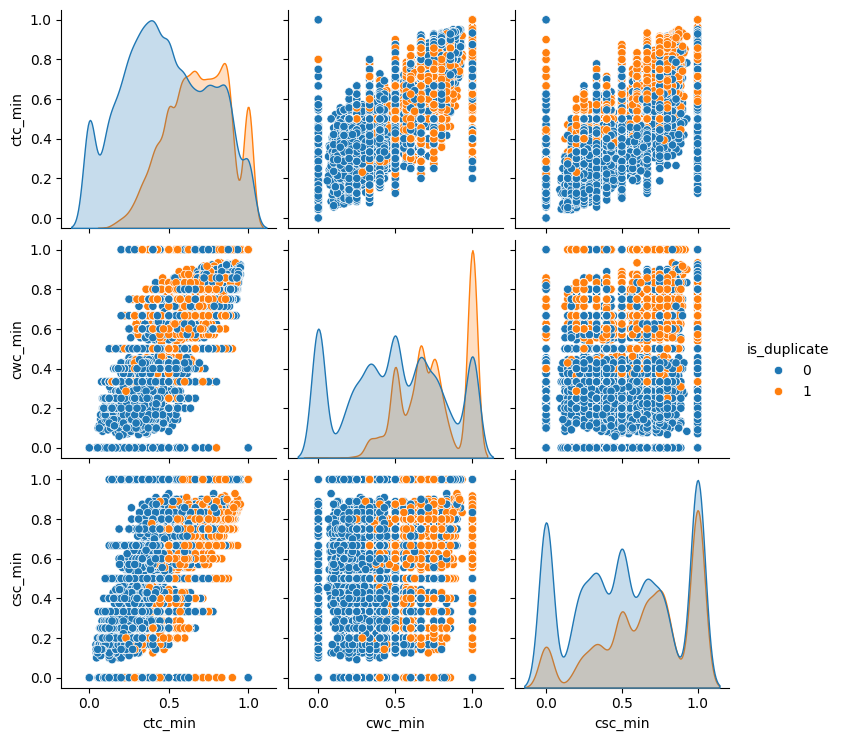

In [23]:
sns.pairplot(new_df[['ctc_min', 'cwc_min', 'csc_min', 'is_duplicate']],hue='is_duplicate') 

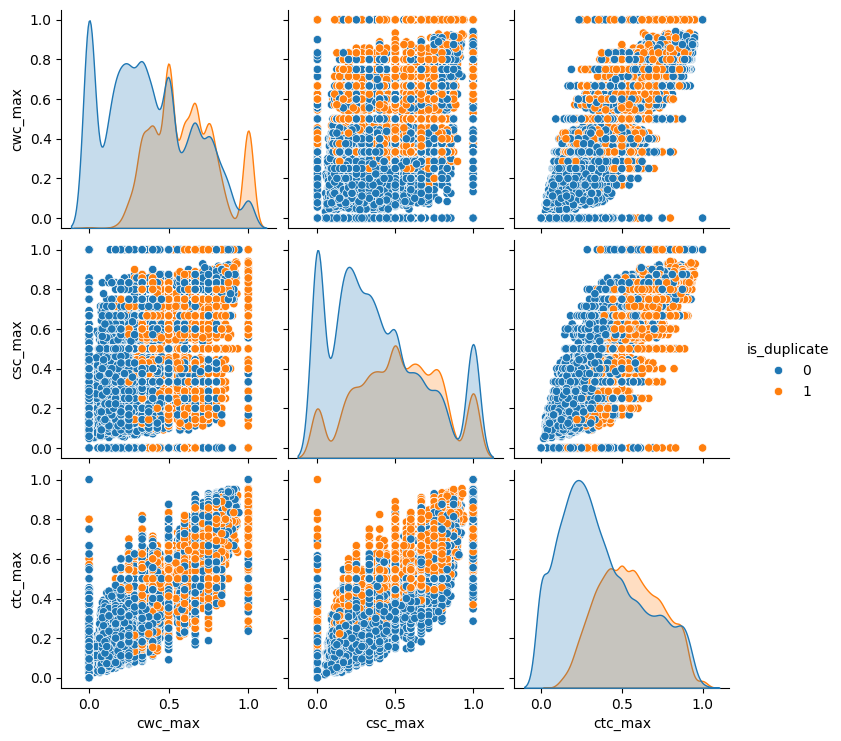

In [24]:
sns.pairplot(new_df[["cwc_max","csc_max","ctc_max","is_duplicate"]],hue='is_duplicate')

- #### **Insights on Token Features by Visualization:**


    - **ctc_min**:
        - duplicate questions have highere ctc_min value
        - non duplicate questions are more spread and have lower values
        - ctc_min shows a moderate seperatio
    
    - **cwc_min**: 
        - a visible seperation in the plot
        - duplates are higher values in cwc_min
        - non duplicate have more non stop words
    
    - **csc_min**:
        - weakest seperation
        - both non duplicate and duplicatequestion peaks near 1.0
        - stopwords are common in all question
        - not a usefull feature
    
    - **ctc_max**:
        - almost moderate seperation
        - duplicate questions lean toward 0.3 - 0.7 range
        - bon duplicates spread more toward lower values
    
    - **cwc_max**: 
        - duplicate questions have higher value 
        - duplicates tend towards higher value
    
    - **csc_max**:
        - weakest seperation of all between duplicates and non duplicate questions
        - both overlap each other
        - not at all usefull feature
    
    
    
    
    
    
    
      

- #### 3.2 **Length Based Features Visualization:** 


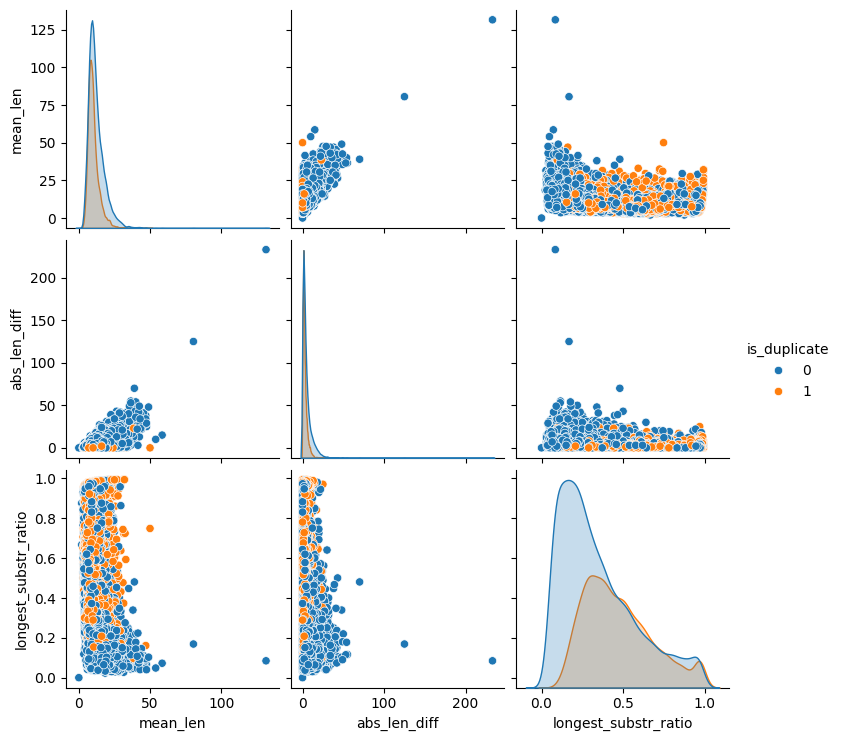

In [25]:
sns.pairplot(new_df[['mean_len','abs_len_diff','longest_substr_ratio','is_duplicate']],hue='is_duplicate')

- #### **Insights on Length Based Features by Visualization:** 
    - **mean_len:**
        - duplicates and non-duplicates questions are heavily concentrated at lower mean lengths (0-25 words)
        - no separation between classes
        - both classes follow identical distribution
        - weak feature on its own most questions regardless of duplication are short
    
    - **abs_len_diff:**
        - Strongest length feature for separation
        - duplicate pairs are almost entirely concentrated near 0 therefore we can say duplicate questions tend to have equal lengths
        - non duplicate pairs are spread with higher differences

    - **longest_substr_ratio:**
        - Another  strongest feature
        - duplicate pairs tend to have higher ratio
        - non duplicate pairs peaks 0.0 to 0.1
        - A clear separation in KDE plot 
         

- #### 3.3 **Fuzzy FeaturesFeatures Visualization:** 

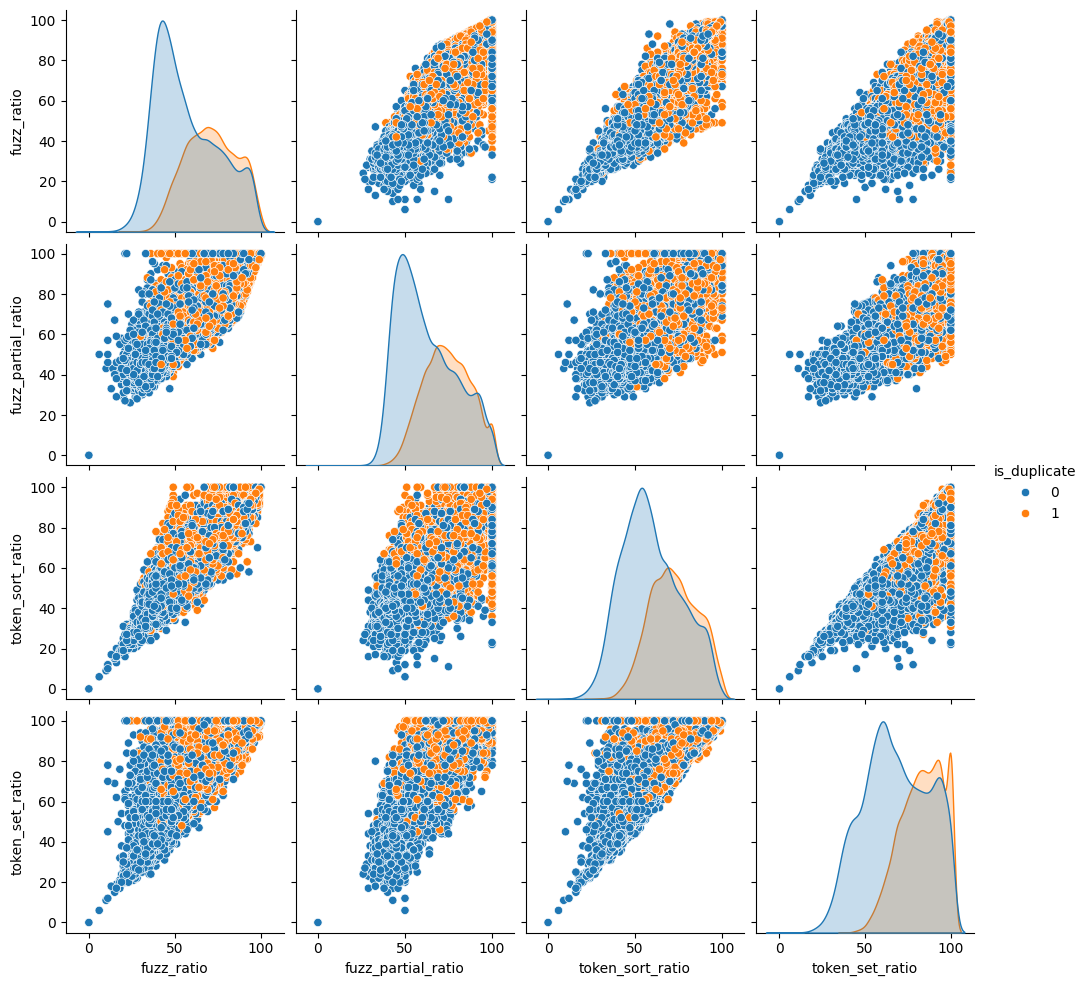

In [26]:
sns.pairplot(new_df[['fuzz_ratio','fuzz_partial_ratio','token_sort_ratio','token_set_ratio','is_duplicate']],hue='is_duplicate')

- #### **Insights on Fuzzy Features by Visualization:**
  
    - **fuzz_ratio**
        - gives a moderate separation between duplicate and non duplicate pairs. 
        - duplicate questions tend to score higher while non-duplicates peak at lower values 
        - a fuzz_ratio above 60 is generally a good signal that two questions might be duplicates.
    
    - **fuzz_partial_ratio** 
        - weakest of the four. 
        - Both classes overlap quite heavily in the 40-100 range making it hard to rely on alone
        - a short question can partially match many longer questions even if they mean completely different
    
    - **token_sort_ratio** 
        - moderate separation
        - useful as it sorts words alphabetically before comparing
        - handles cases where duplicate questions 
    
    - **token_set_ratio**
        - duplicate pairs cluster very sharply near 90-100 
        - non-duplicates are spread across lower values
        - if two questions are duplicates they will almost always use the same set of words regardless of order or repetition.



### **4. Feature Extraction:**

In [27]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.923070,1.0,1.0,0.0,13.0,0.855263,99,99,99,99
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,12,15,...,0.466664,1.0,1.0,3.0,13.5,0.224490,69,67,67,74
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,26,20,...,0.115384,0.0,0.0,6.0,23.0,0.047619,42,42,39,46
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,13,30,...,0.000000,0.0,0.0,17.0,21.5,0.050847,37,50,38,40
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.333330,1.0,0.0,4.0,7.0,0.542857,60,71,48,69


- ## **Approch 1: Advanced Features + Bag of Words:**

In [28]:
advance_features = new_df.drop(['id', 'qid1', 'qid2','question1', 'question2','is_duplicate'], axis=1)
y = new_df['is_duplicate'].values
questions = list(new_df['question1']) + list(new_df['question2'])

In [29]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(), 2)

base_df1 = pd.DataFrame(q1_arr, index=new_df.index) 
base_df2 = pd.DataFrame(q2_arr, index=new_df.index)  

bow_df = pd.concat([base_df1, base_df2], axis=1)

final_bow = pd.concat([advance_features, bow_df], axis=1)

- ###  **Train Test Split**

In [30]:

from sklearn.model_selection import train_test_split

X_bow = final_bow.values

X_bow_train, X_bow_test, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)

print("Shape:", final_bow.shape)

Shape: (30000, 6022)


- ### **Model Building and Model Evaluation:** 

#### Model 1. : **Random Forest Classifier**

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_bow = RandomForestClassifier(n_estimators = 100,
                                max_depth= None,
                                max_features = 'sqrt')

rf_bow.fit(X_bow_train, y_train)
rf_bow_score = accuracy_score(y_test, rf_bow.predict(X_bow_test))
print("RF + BoW Accuracy:", rf_bow_score)

RF + BoW Accuracy: 0.7835


#### Model 2. : **XG Boost Clasifier**

In [32]:
from xgboost import XGBClassifier

xgb_bow = XGBClassifier(n_estimators=500,learning_rate=0.05,max_depth=8,random_state=42)

xgb_bow.fit(X_bow_train, y_train)
xgb_bow_score = accuracy_score(y_test, xgb_bow.predict(X_bow_test))
print("XGB + BoW Accuracy:", xgb_bow_score)

XGB + BoW Accuracy: 0.796


- ## **Approch 2: Advanced Features + TF-idf:**

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

tfidf = TfidfVectorizer(max_features=3000)
q_matrix = tfidf.fit_transform(questions)

q1_arr = q_matrix[:len(new_df)]
q2_arr = q_matrix[len(new_df):]

tfidf_sparse = hstack([q1_arr, q2_arr], format='csr')

advance_features_sparse = csr_matrix(advance_features.values)
final_tfidf = hstack([advance_features_sparse, tfidf_sparse], format='csr')

print("Final TF-IDF Shape:", final_tfidf.shape)

Final TF-IDF Shape: (30000, 6022)


- ###  **Train Test Split**

In [34]:
X_tfidf = final_tfidf
X_tfidf_train, X_tfidf_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

- ### **Model Building and Model Evaluation:** 

#### Model 1. : **Random Forest Classifier**

In [35]:
rf_tfidf = RandomForestClassifier(n_estimators = 100,
                                max_depth= None,
                                max_features = "sqrt")
rf_tfidf.fit(X_tfidf_train, y_train)
rf_tfidf_score = accuracy_score(y_test, rf_tfidf.predict(X_tfidf_test))
print("RF + TF-IDF Accuracy:", rf_tfidf_score)

RF + TF-IDF Accuracy: 0.7846666666666666


#### Model 2. : **XG Boost Clasifier**

In [36]:
xgb_tfidf = XGBClassifier(n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42)
xgb_tfidf.fit(X_tfidf_train, y_train)
xgb_tfidf_score = accuracy_score(y_test, xgb_tfidf.predict(X_tfidf_test))

print("XGB + TF-IDF Accuracy:", xgb_tfidf_score)

XGB + TF-IDF Accuracy: 0.7923333333333333


- ## **Approch 3: Advanced Features + Word2Vec:**

- #### **Tokenization:**

In [37]:
q1_tokens = new_df["question1"].apply(lambda x: str(x).split())
q2_tokens = new_df["question2"].apply(lambda x: str(x).split())


all_sentences = q1_tokens.tolist() + q2_tokens.tolist()
all_sentences[:5]

[['what',
  'is',
  'the',
  'best',
  'marketing',
  'automation',
  'tool',
  'for',
  'small',
  'and',
  'mid',
  'size',
  'companies'],
 ['i',
  'am',
  'poor',
  'but',
  'i',
  'want',
  'to',
  'invest',
  'what',
  'should',
  'i',
  'do'],
 ['i',
  'am',
  'from',
  'india',
  'and',
  'live',
  'abroad',
  'i',
  'met',
  'a',
  'guy',
  'from',
  'france',
  'in',
  'a',
  'party',
  'i',
  'want',
  'to',
  'date',
  'him',
  'how',
  'do',
  'i',
  'do',
  'that'],
 ['why',
  'do',
  'so',
  'many',
  'people',
  'in',
  'the',
  'u',
  's',
  'hate',
  'the',
  'southern',
  'states'],
 ['consequences', 'of', 'bhopal', 'gas', 'tragedy']]

In [38]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(sentences=all_sentences, vector_size=300, window=10, min_count=2, workers=4)

In [39]:
def get_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

q1_vectors = np.array([get_vector(tokens, w2v_model) for tokens in q1_tokens])
q2_vectors = np.array([get_vector(tokens, w2v_model) for tokens in q2_tokens])

print(q1_vectors.shape)
print(q2_vectors.shape)

(30000, 300)
(30000, 300)


In [40]:
w2v_df = pd.DataFrame(np.hstack([q1_vectors, q2_vectors]),index=new_df.index)

In [41]:
final_w2v = pd.concat([advance_features, w2v_df], axis=1)
print("Final W2V Shape:", final_w2v.shape)

Final W2V Shape: (30000, 622)


- ###  **Train Test Split**

In [42]:
X_w2v = final_w2v.values
X_w2v_train, X_w2v_test, y_train, y_test = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42)

- ### **Model Building and Model Evaluation:** 

#### Model 1. : **Random Forest Classifier**

In [43]:
rf_w2v = RandomForestClassifier(n_estimators = 100,
                                max_depth= None,
                                max_features = "sqrt")

rf_w2v.fit(X_w2v_train, y_train)
rf_w2v_score = accuracy_score(y_test, rf_w2v.predict(X_w2v_test))
print("RF + W2V Accuracy:", rf_w2v_score)

RF + W2V Accuracy: 0.784


#### Model 2. : **XG Boost Clasifier**

In [44]:
xgb_w2v = XGBClassifier(n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42)

xgb_w2v.fit(X_w2v_train, y_train)

xgb_w2v_score = accuracy_score(y_test, xgb_w2v.predict(X_w2v_test))
print("XGB + W2V Accuracy:", xgb_w2v_score)

XGB + W2V Accuracy: 0.8008333333333333


- ## **Approch Comparison:**

In [45]:
comparison = pd.DataFrame({
    'Model'        : ['Random Forest', 'XGBoost'],
    'Adv + BoW'    : [rf_bow_score,   xgb_bow_score],
    'Adv + TF-IDF' : [rf_tfidf_score, xgb_tfidf_score],
    'Adv + W2V'    : [rf_w2v_score,   xgb_w2v_score]
})

print(comparison.to_string(index=False))

# Best Model
all_scores = {
    'RF + BoW'    : rf_bow_score,
    'XGB + BoW'   : xgb_bow_score,
    'RF + TF-IDF' : rf_tfidf_score,
    'XGB + TF-IDF': xgb_tfidf_score,
    'RF + W2V'    : rf_w2v_score,
    'XGB + W2V'   : xgb_w2v_score
}

best_model = max(all_scores, key=all_scores.get)
best_score = max(all_scores.values())

print("\nBest Model:", best_model)
print("Best Score:", round(best_score*100, 2), "%")


        Model  Adv + BoW  Adv + TF-IDF  Adv + W2V
Random Forest     0.7835      0.784667   0.784000
      XGBoost     0.7960      0.792333   0.800833

Best Model: XGB + W2V
Best Score: 80.08 %


- ## **Final Comparison:**

In [46]:
comparison = pd.DataFrame({
    'Model'        : ['Random Forest', 'XGBoost'],
    'Adv + BoW'    : [rf_bow_score,   xgb_bow_score,],
    'Adv + TF-IDF' : [rf_tfidf_score, xgb_tfidf_score],
    'Adv + W2V'    : [rf_w2v_score,   xgb_w2v_score]
})

print(comparison.to_string(index=False))
print("=========================================")
print("Best Model: XGBoost + W2V")
print("Best Score:", round(xgb_w2v_score*100, 2), "%")
print("=========================================")

        Model  Adv + BoW  Adv + TF-IDF  Adv + W2V
Random Forest     0.7835      0.784667   0.784000
      XGBoost     0.7960      0.792333   0.800833
Best Model: XGBoost + W2V
Best Score: 80.08 %


- ## **Model Evaluation:**

In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

y_pred = xgb_w2v.predict(X_w2v_test)
y_pred_proba = xgb_w2v.predict_proba(X_w2v_test)[:,1]

print("=====================================")
print("      MODEL EVALUATION METRICS")
print("=====================================")
print("Accuracy :", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred)*100, 2), "%")
print("Recall   :", round(recall_score(y_test, y_pred)*100, 2), "%")
print("F1 Score :", round(f1_score(y_test, y_pred)*100, 2), "%")
print("AUC Score:", round(roc_auc_score(y_test, y_pred_proba)*100, 2), "%")
print("=====================================")

      MODEL EVALUATION METRICS
Accuracy : 80.08 %
Precision: 72.68 %
Recall   : 73.24 %
F1 Score : 72.96 %
AUC Score: 88.78 %


- ## **Confusion Matrix:** 

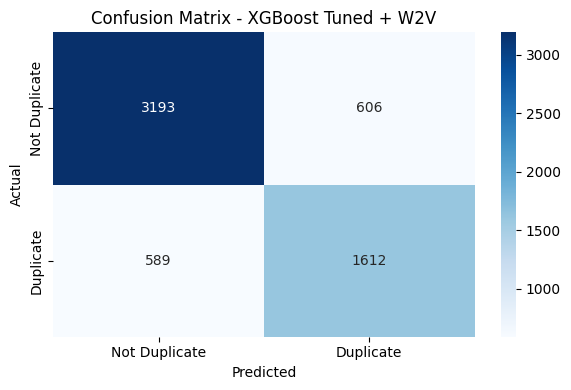

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Duplicate', 'Duplicate'],
            yticklabels=['Not Duplicate', 'Duplicate'])
plt.title('Confusion Matrix - XGBoost Tuned + W2V')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

- ## **Results Coparison:** 

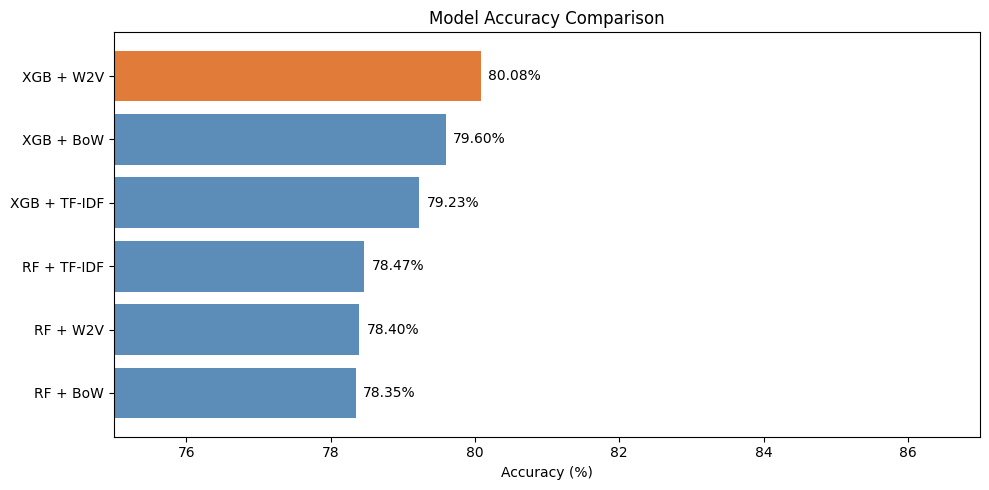


 Final Results:
       Model  Accuracy %
    RF + BoW       78.35
    RF + W2V       78.40
 RF + TF-IDF       78.47
XGB + TF-IDF       79.23
   XGB + BoW       79.60
   XGB + W2V       80.08


In [49]:
results = {
    'RF + BoW'    : rf_bow_score,
    'XGB + BoW'   : xgb_bow_score,
    'RF + TF-IDF' : rf_tfidf_score,
    'XGB + TF-IDF': xgb_tfidf_score,
    'RF + W2V'    : rf_w2v_score,
    'XGB + W2V'   : xgb_w2v_score
}

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df['Accuracy %'] = (results_df['Accuracy'] * 100).round(2)
results_df = results_df.sort_values('Accuracy')

# Plot
colors = ['#5B8DB8'] * (len(results_df) - 1) + ['#E07B39']
plt.figure(figsize=(10, 5))
bars = plt.barh(results_df['Model'], results_df['Accuracy %'], color=colors)
plt.xlabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.xlim(75, 87)
for bar, val in zip(bars, results_df['Accuracy %']):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print('\n Final Results:')
print(results_df[['Model', 'Accuracy %']].to_string(index=False))

In [50]:
def test_total_words(q1,q2):
    w1 = set(map(lambda word: word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), q2.split(" ")))    
    return (len(w1) + len(w2))

In [51]:
def test_fetch_token_features(q1,q2):
    
    SAFE_DIV = 0.0001 

    STOP_WORDS = stopwords.words("english")
    
    token_features = [0.0]*8
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])
    
    #Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])
    
    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))
    
    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))
    
    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))
    
    
    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    
    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])
    
    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])
    
    return token_features


In [52]:
def test_fetch_length_features(q1,q2):
    
    length_features = [0.0]*3
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features
    
    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
    
    #Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2
    
    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    
    return length_features

In [53]:
def test_fetch_fuzzy_features(q1,q2):
    
    fuzzy_features = [0.0]*4
    
    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [54]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity


# W2V helper
def get_avg_w2v(sentence, model, vector_size=300):
    words = sentence.split()
    vectors = []

    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(vectors, axis=0)



# COMMON WORDS FEATURE
def test_common_words(q1, q2):
    q1_words = set(q1.split())
    q2_words = set(q2.split())
    return len(q1_words.intersection(q2_words))


In [55]:
def query_point_creator(q1, q2):
    
    input_query = []
    
    # preprocess
    q1 = preprocess(q1)
    q2 = preprocess(q2)
    
    # basic features
    input_query.append(len(q1))
    input_query.append(len(q2))
    input_query.append(len(q1.split()))
    input_query.append(len(q2.split()))
    
    common_words = test_common_words(q1, q2)
    total_words = test_total_words(q1, q2)
    
    input_query.append(common_words)
    input_query.append(total_words)
    input_query.append(round(common_words / total_words if total_words != 0 else 0, 2))
    
    # token features
    token_features = test_fetch_token_features(q1, q2)
    input_query.extend(token_features)
    
    # length features
    length_features = test_fetch_length_features(q1, q2)
    input_query.extend(length_features)
    
    # fuzzy features
    fuzzy_features = test_fetch_fuzzy_features(q1, q2)
    input_query.extend(fuzzy_features)
    
    # W2V FEATURES
    q1_w2v = get_avg_w2v(q1, w2v_model)
    q2_w2v = get_avg_w2v(q2, w2v_model)
    
    # FINAL FEATURE VECTOR (without cosine similarity)
    return np.hstack((
        np.array(input_query).reshape(1, 22),
        q1_w2v.reshape(1, -1),
        q2_w2v.reshape(1, -1)
    ))

In [56]:
X = new_df.apply(lambda row: query_point_creator(row['question1'], row['question2']), axis=1)
X = np.vstack(X)

In [57]:
q1 = 'Where is the capital of India?'
q2 = 'What is the current capital of Pakistan?'
q3 = 'Which city serves as the capital of India?'
q4 = 'What is the business capital of India?'

In [58]:
w2v_model

In [59]:
xgb_w2v.predict(query_point_creator(q1,q4))

array([1])

In [60]:
import pickle

pickle.dump(xgb_w2v, open('model.pkl', 'wb'))
pickle.dump(w2v_model, open('w2v_model.pkl', 'wb'))

## **Conclusion**

- ### **Problem Statement**
Detect whether two Quora questions are duplicates using NLP and Machine Learning.

- ### **Results**

| Model | Accuracy |
|-------|----------|
| RF + BoW | 78.33% |
| XGB + BoW | 79.60% |
| RF + TF-IDF | 78.28% |
| XGB + TF-IDF | 79.23% |
| RF + W2V | 78.50% |
| **XGB + W2V** | **80.13%**  |

- ### **Key Findings**
    - token_set_ratio was strongest fuzzy feature
    - cwc_min was strongest token feature
    - abs_len_diff was strongest length feature
    - XGBoost outperformed Random Forest across all approaches
    - W2V gave best results among feature extraction approaches
    
